In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path

In [4]:
adata = sc.read_h5ad("../results/liver_log_normalized_annotated_for_DE.h5ad")

In [5]:
print(adata)

AnnData object with n_obs × n_vars = 60455 × 33694
    obs: 'sample_id', 'condition', 'cd45_status', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'condition_colors', 'hvg', 'log1p', 'rank_genes_groups'
    layers: 'counts'


In [6]:
pd.crosstab(
    adata.obs["cell_type"],
    adata.obs["condition"]
)

condition,cirrhotic,healthy
cell_type,,
Cholangiocyte,2412,1133
Endothelial,4774,3064
Fibroblast_Stellate,242,54
Hepatocyte,1859,2340
Mast,35,57
Myeloid,4494,6411
NK_cells,3220,8654
Plasma_cells,689,544
T_cells,7773,12700


In [7]:
cell_counts = pd.crosstab(
    adata.obs["cell_type"],
    adata.obs["condition"],
    normalize="columns"
) * 100

cell_counts

condition,cirrhotic,healthy
cell_type,,
Cholangiocyte,9.459565,3.241125
Endothelial,18.723037,8.765054
Fibroblast_Stellate,0.949094,0.154475
Hepatocyte,7.290768,6.693938
Mast,0.137266,0.163057
Myeloid,17.624912,18.339674
NK_cells,12.628441,24.756129
Plasma_cells,2.702173,1.556198
T_cells,30.484744,36.330349


<Axes: xlabel='cell_type', ylabel='% of cells'>

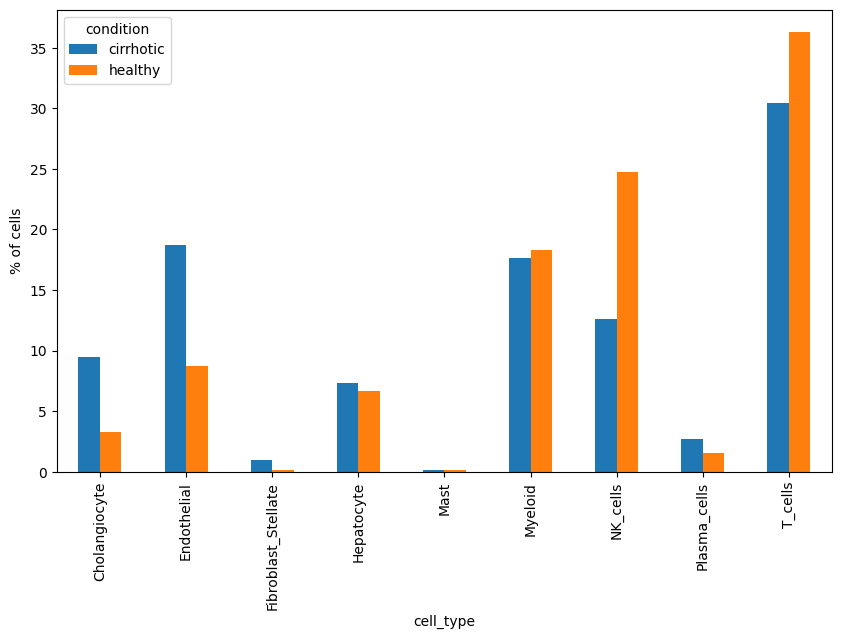

In [8]:
cell_counts.plot(
    kind="bar",
    figsize=(10,6),
    ylabel="% of cells"
)

In [9]:
results = []

cell_types = sorted(adata.obs["cell_type"].unique())

for ct in cell_types:

    subset = adata[
        adata.obs["cell_type"] == ct
    ].copy()

    counts = subset.obs["condition"].value_counts()

    print(f"\n{ct}")
    print(counts)

    # skip tiny groups
    if (
        len(counts) < 2
        or counts.min() < 20
    ):
        print("Skipping")
        continue

    sc.tl.rank_genes_groups(
        subset,
        groupby="condition",
        groups=["cirrhotic"],
        reference="healthy",
        method="wilcoxon"
    )

    df = sc.get.rank_genes_groups_df(
        subset,
        group="cirrhotic"
    )

    df["cell_type"] = ct

    results.append(df)


Cholangiocyte
condition
cirrhotic    2412
healthy      1133
Name: count, dtype: int64

Endothelial
condition
cirrhotic    4774
healthy      3064
Name: count, dtype: int64

Fibroblast_Stellate
condition
cirrhotic    242
healthy       54
Name: count, dtype: int64

Hepatocyte
condition
healthy      2340
cirrhotic    1859
Name: count, dtype: int64

Mast
condition
healthy      57
cirrhotic    35
Name: count, dtype: int64

Myeloid
condition
healthy      6411
cirrhotic    4494
Name: count, dtype: int64

NK_cells
condition
healthy      8654
cirrhotic    3220
Name: count, dtype: int64

Plasma_cells
condition
cirrhotic    689
healthy      544
Name: count, dtype: int64

T_cells
condition
healthy      12700
cirrhotic     7773
Name: count, dtype: int64


In [10]:
de_results = pd.concat(results)

de_results.head()

,names,scores,logfoldchanges,pvals,pvals_adj,cell_type
0,UQCRB,30.311480,1.958040,8.092020e-202,2.726525e-197,Cholangiocyte
1,MT-CYB,29.990917,1.169831,1.289035e-197,2.171636e-193,Cholangiocyte
2,MT-ND1,27.702662,1.114378,6.485303e-169,7.283860e-165,Cholangiocyte
3,MT-ND3,26.838627,1.158005,1.145086e-158,9.645636e-155,Cholangiocyte
4,MT-ATP6,26.344173,1.104618,5.985209e-153,4.033312e-149,Cholangiocyte


In [11]:
de_results.to_csv(
    "../results/celltype_DE_all.csv",
    index=False
)

In [12]:
de_results[
    (de_results["pvals_adj"] < 0.05)
    &
    (de_results["logfoldchanges"] > 1)
].sort_values(
    "scores",
    ascending=False
).head(50)

,names,scores,logfoldchanges,pvals,pvals_adj,cell_type
0,IGKC,73.163879,2.509495,0.000000e+00,0.000000e+00,T_cells
1,IGLC2,55.518120,2.740479,0.000000e+00,0.000000e+00,T_cells
2,CXCR4,51.229885,1.606308,0.000000e+00,0.000000e+00,T_cells
0,VWF,49.379536,3.048305,0.000000e+00,0.000000e+00,Endothelial
1,RPL36A,47.040642,1.642942,0.000000e+00,0.000000e+00,Endothelial
3,IGLC3,46.605591,2.666482,0.000000e+00,0.000000e+00,T_cells
3,SPARCL1,45.806961,2.830835,0.000000e+00,0.000000e+00,Endothelial
4,MT-CYB,44.943771,1.005664,0.000000e+00,0.000000e+00,T_cells
8,VWA1,40.190941,3.743970,0.000000e+00,0.000000e+00,Endothelial
5,VIM,40.067444,1.379638,0.000000e+00,0.000000e+00,T_cells


In [13]:
adata.obs["cell_type"].value_counts()

cell_type
T_cells                20473
NK_cells               11874
Myeloid                10905
Endothelial             7838
Hepatocyte              4199
Cholangiocyte           3545
Plasma_cells            1233
Fibroblast_Stellate      296
Mast                      92
Name: count, dtype: int64

In [14]:
print(adata.obs["cell_type"].value_counts())

cell_type
T_cells                20473
NK_cells               11874
Myeloid                10905
Endothelial             7838
Hepatocyte              4199
Cholangiocyte           3545
Plasma_cells            1233
Fibroblast_Stellate      296
Mast                      92
Name: count, dtype: int64


In [16]:
adata_hvg = sc.read_h5ad(
    "../results/liver_hvg_clustered_annotated.h5ad"
)

adata_hvg

AnnData object with n_obs × n_vars = 60455 × 3000
    obs: 'sample_id', 'condition', 'cd45_status', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cd45_status_colors', 'cell_type_colors', 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [18]:
adata_hvg = sc.read_h5ad(
    "../results/liver_hvg_clustered_annotated.h5ad"
)

adata_hvg

AnnData object with n_obs × n_vars = 60455 × 3000
    obs: 'sample_id', 'condition', 'cd45_status', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cd45_status_colors', 'cell_type_colors', 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [19]:
adata = sc.read_h5ad(
    "../results/liver_log_normalized_annotated_for_DE.h5ad"
)

adata

AnnData object with n_obs × n_vars = 60455 × 33694
    obs: 'sample_id', 'condition', 'cd45_status', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'condition_colors', 'hvg', 'log1p', 'rank_genes_groups'
    layers: 'counts'

In [20]:
pd.crosstab(
    adata.obs["cell_type"],
    adata.obs["condition"]
)

condition,cirrhotic,healthy
cell_type,,
Cholangiocyte,2412,1133
Endothelial,4774,3064
Fibroblast_Stellate,242,54
Hepatocyte,1859,2340
Mast,35,57
Myeloid,4494,6411
NK_cells,3220,8654
Plasma_cells,689,544
T_cells,7773,12700


In [22]:
results = []

for ct in sorted(adata.obs["cell_type"].unique()):

    print(f"\nRunning DE for {ct}")

    subset = adata[
        adata.obs["cell_type"] == ct
    ].copy()

    sc.tl.rank_genes_groups(
        subset,
        groupby="condition",
        groups=["cirrhotic"],
        reference="healthy",
        method="wilcoxon"
    )

    df = sc.get.rank_genes_groups_df(
        subset,
        group="cirrhotic"
    )

    df["cell_type"] = ct

    results.append(df)

de_results = pd.concat(results)

de_results.head()


Running DE for Cholangiocyte

Running DE for Endothelial

Running DE for Fibroblast_Stellate

Running DE for Hepatocyte

Running DE for Mast

Running DE for Myeloid

Running DE for NK_cells

Running DE for Plasma_cells

Running DE for T_cells


,names,scores,logfoldchanges,pvals,pvals_adj,cell_type
0,UQCRB,30.311480,1.958040,8.092020e-202,2.726525e-197,Cholangiocyte
1,MT-CYB,29.990917,1.169831,1.289035e-197,2.171636e-193,Cholangiocyte
2,MT-ND1,27.702662,1.114378,6.485303e-169,7.283860e-165,Cholangiocyte
3,MT-ND3,26.838627,1.158005,1.145086e-158,9.645636e-155,Cholangiocyte
4,MT-ATP6,26.344173,1.104618,5.985209e-153,4.033312e-149,Cholangiocyte


In [23]:
de_results.to_csv(
    "../results/liver_DE_by_celltype.csv",
    index=False
)

print(de_results.shape)

(303246, 6)


In [24]:
de_results[
    (de_results["cell_type"] == "Fibroblast_Stellate")
    &
    (de_results["pvals_adj"] < 0.05)
].sort_values(
    "logfoldchanges",
    ascending=False
).head(30)

,names,scores,logfoldchanges,pvals,pvals_adj,cell_type
19,HRCT1,4.374800,3.531891,1.215438e-05,1.170085e-02,Fibroblast_Stellate
14,TGM2,4.654379,1.976689,3.249581e-06,4.211206e-03,Fibroblast_Stellate
22,IL32,4.202481,1.839166,2.640057e-05,2.223852e-02,Fibroblast_Stellate
0,S100A11,6.776720,1.815604,1.229348e-11,2.071082e-07,Fibroblast_Stellate
9,C4orf48,4.860107,1.582635,1.173220e-06,2.075383e-03,Fibroblast_Stellate
3,IFITM2,6.282621,1.500678,3.329123e-10,1.869524e-06,Fibroblast_Stellate
12,LGALS1,4.803840,1.369876,1.556513e-06,2.280223e-03,Fibroblast_Stellate
2,PFN1,6.461094,1.235100,1.039484e-10,7.004877e-07,Fibroblast_Stellate
23,CCL21,4.160280,1.230446,3.178575e-05,2.612168e-02,Fibroblast_Stellate
1,RPS26,6.549891,1.130849,5.757886e-11,6.466874e-07,Fibroblast_Stellate


In [25]:
de_results[
    (de_results["cell_type"]=="Fibroblast_Stellate")
    &
    (
        de_results["names"].isin([
            "COL1A1",
            "COL1A2",
            "COL3A1",
            "ACTA2",
            "TAGLN",
            "SPARC",
            "DCN",
            "LUM"
        ])
    )
]

,names,scores,logfoldchanges,pvals,pvals_adj,cell_type
873,SPARC,1.186893,0.384337,0.235270,1.0,Fibroblast_Stellate
3391,COL1A2,0.379806,25.095413,0.704090,1.0,Fibroblast_Stellate
3678,COL1A1,0.332330,24.801775,0.739640,1.0,Fibroblast_Stellate
4650,LUM,0.237379,24.343607,0.812363,1.0,Fibroblast_Stellate
6214,COL3A1,0.122206,1.139890,0.902736,1.0,Fibroblast_Stellate
27174,DCN,-0.021100,-0.102392,0.983166,1.0,Fibroblast_Stellate
27374,TAGLN,-0.029892,-0.013124,0.976153,1.0,Fibroblast_Stellate
32582,ACTA2,-0.734115,-1.435707,0.462878,1.0,Fibroblast_Stellate



 COL1A1


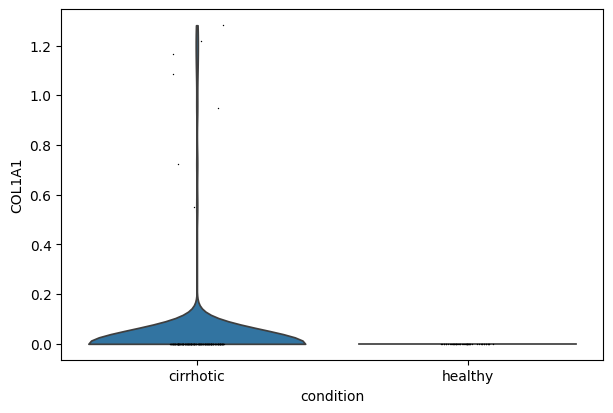


 COL1A2


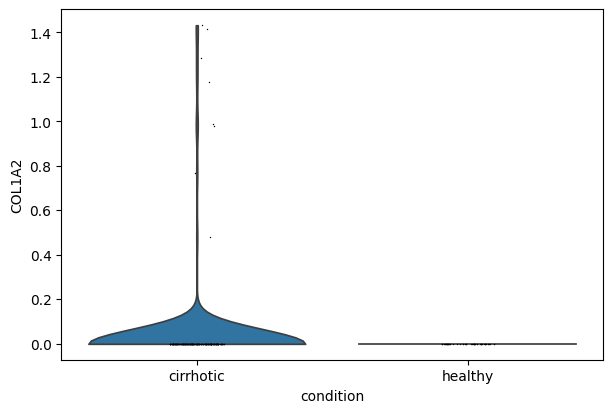


 COL3A1


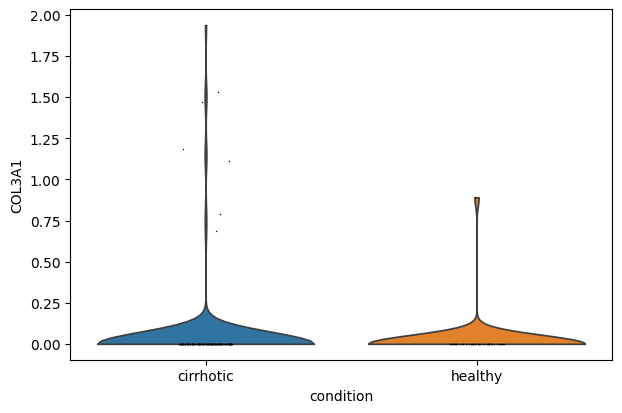


 ACTA2


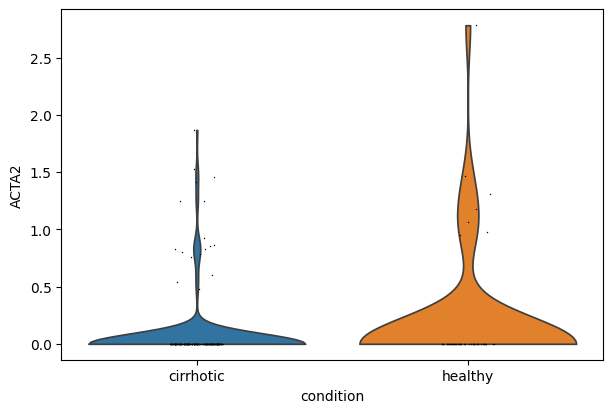


 TIMP1


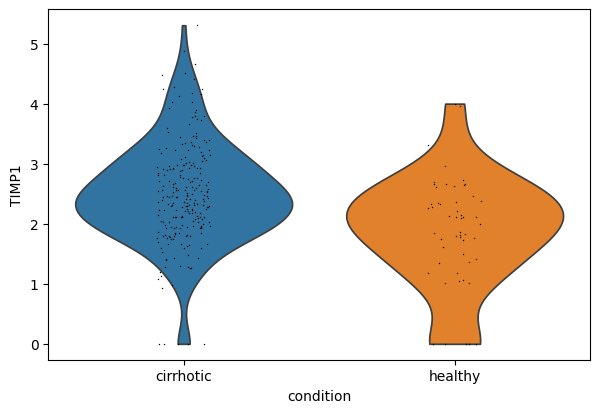


 TGM2


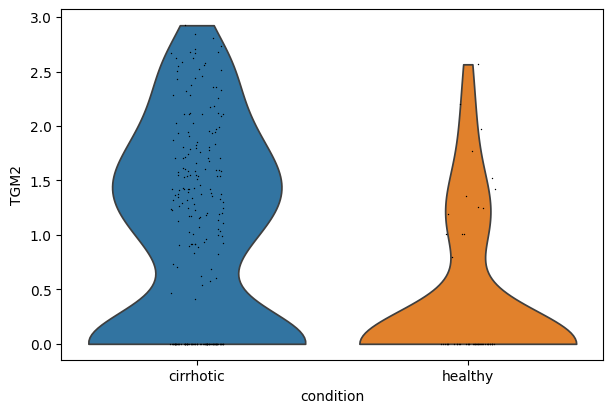

In [26]:
fibro = adata[
    adata.obs["cell_type"] == "Fibroblast_Stellate"
].copy()

for gene in ["COL1A1","COL1A2","COL3A1","ACTA2","TIMP1","TGM2"]:
    print("\n", gene)

    sc.pl.violin(
        fibro,
        keys=gene,
        groupby="condition"
    )

In [28]:
fibro = adata[
    adata.obs["cell_type"] == "Fibroblast_Stellate"
].copy()

fibro

AnnData object with n_obs × n_vars = 296 × 33694
    obs: 'sample_id', 'condition', 'cd45_status', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'condition_colors', 'hvg', 'log1p', 'rank_genes_groups'
    layers: 'counts'

In [29]:
sc.pp.highly_variable_genes(fibro)

sc.pp.scale(fibro, max_value=10)

sc.tl.pca(fibro)

sc.pp.neighbors(fibro)

sc.tl.umap(fibro)

sc.tl.leiden(fibro, resolution=0.3)

/opt/homebrew/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/functools.py:931: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/var/folders/b2/ymzq2wt53615yjqtzdy4y7_00000gn/T/ipykernel_38778/2959911389.py:11: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(fibro, resolution=0.3)


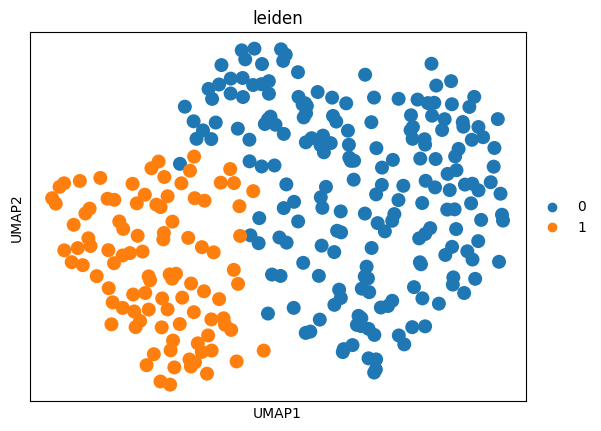

In [30]:
sc.pl.umap(
    fibro,
    color=["leiden"]
)

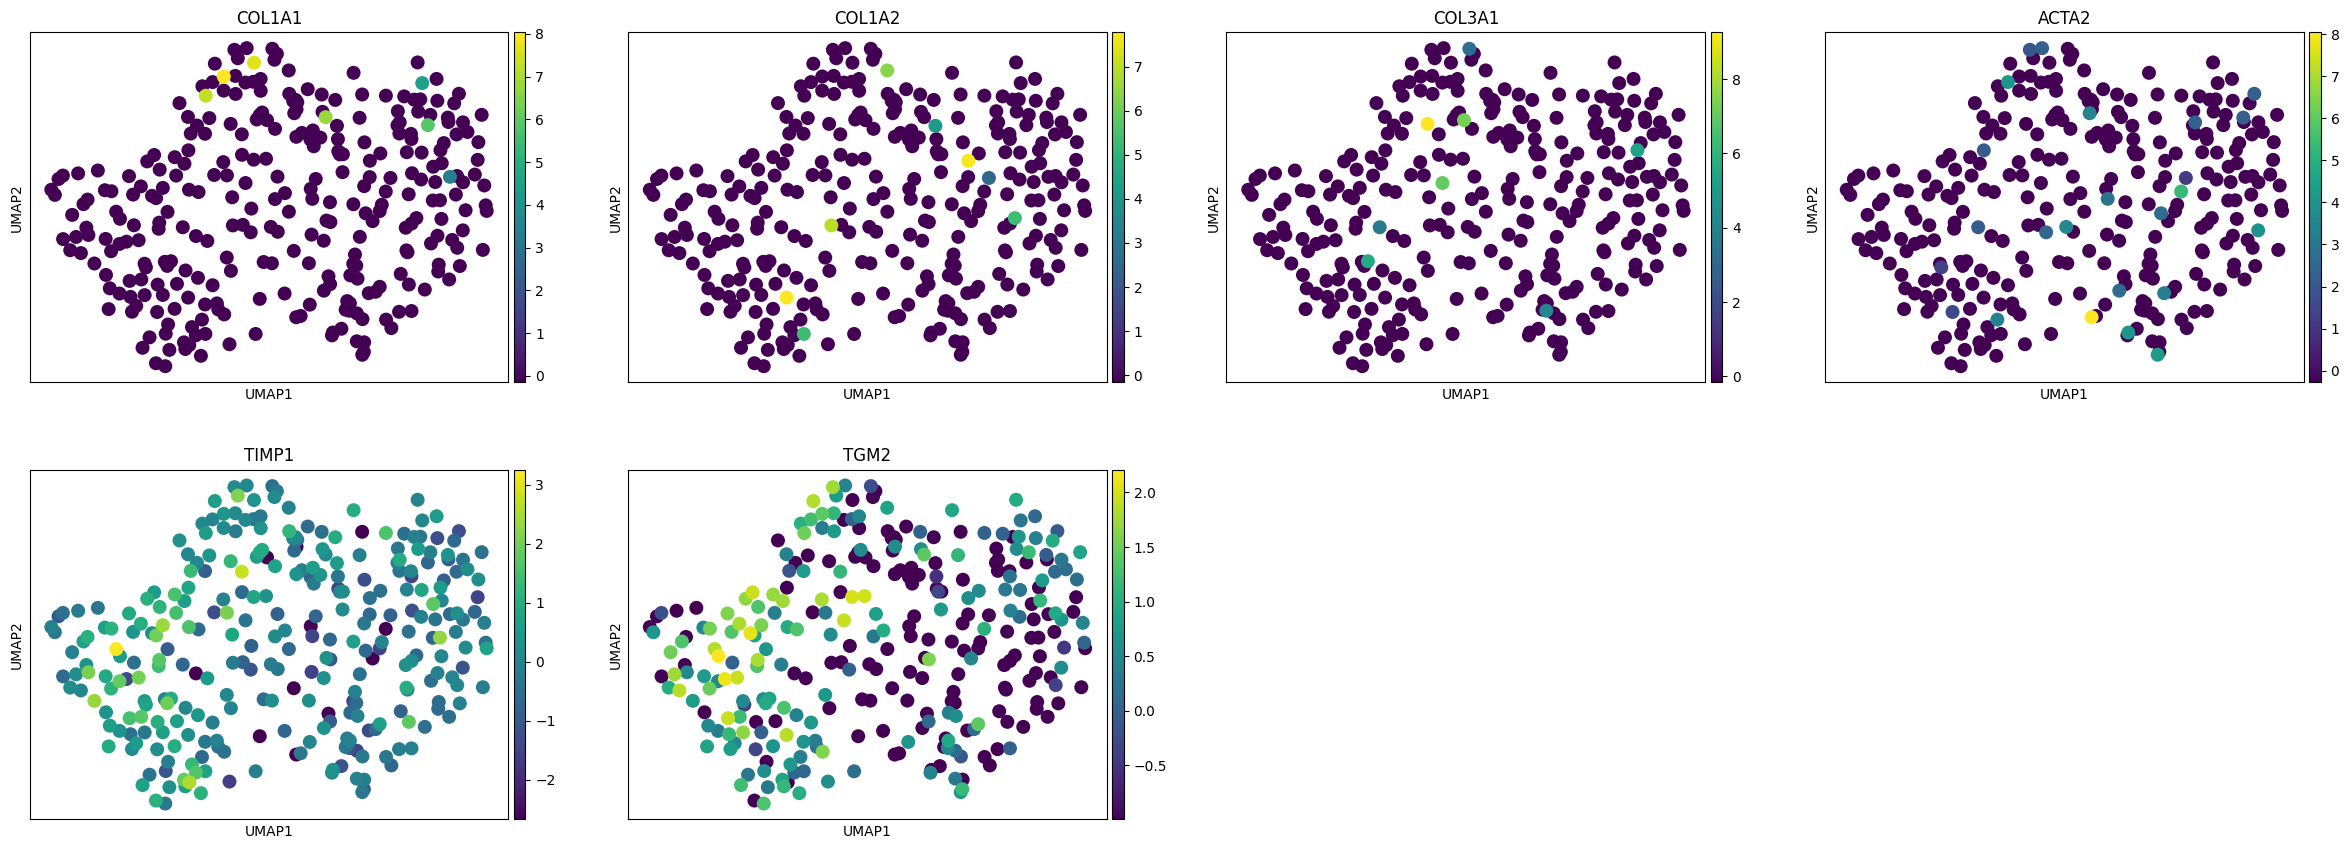

In [31]:
sc.pl.umap(
    fibro,
    color=[
        "COL1A1",
        "COL1A2",
        "COL3A1",
        "ACTA2",
        "TIMP1",
        "TGM2"
    ]
)

In [32]:
pd.crosstab(
    fibro.obs["leiden"],
    fibro.obs["condition"],
    normalize="columns"
) * 100

condition,cirrhotic,healthy
leiden,,
0,59.917355,96.296296
1,40.082645,3.703704


In [33]:
sc.tl.rank_genes_groups(
    fibro,
    groupby="leiden",
    groups=["1"],
    reference="0",
    method="wilcoxon"
)

sc.get.rank_genes_groups_df(
    fibro,
    group="1"
).head(30)

/Users/op/Documents/Karyon Bio Single Cell Project/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


,names,scores,logfoldchanges,pvals,pvals_adj
0,TPT1,11.617587,NaN,3.354773e-31,1.130357e-26
1,EFEMP1,10.032161,NaN,1.100812e-23,1.854539e-19
2,PDLIM1,9.598921,NaN,8.078588e-22,9.073331e-18
3,RPL37,9.242685,NaN,2.403868e-20,2.024898e-16
4,TFPI,8.985765,NaN,2.569422e-19,1.731482e-15
5,RPS12,8.900124,NaN,5.578437e-19,3.132665e-15
6,RPL13,8.867739,NaN,7.464611e-19,3.593037e-15
7,RPL36A,8.693580,NaN,3.511959e-18,1.479149e-14
8,RPS15A,8.364692,NaN,6.027240e-17,2.030818e-13
9,RPS27,8.191972,NaN,2.569817e-16,7.871582e-13


In [34]:
pd.crosstab(
    fibro.obs["leiden"],
    fibro.obs["condition"]
)

condition,cirrhotic,healthy
leiden,,
0,145,52
1,97,2


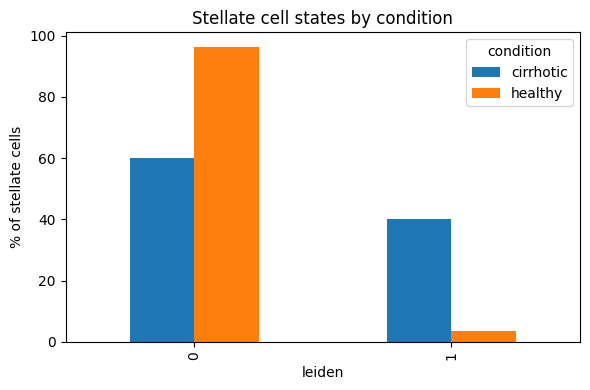

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_props = (
    pd.crosstab(
        fibro.obs["leiden"],
        fibro.obs["condition"],
        normalize="columns"
    ) * 100
)

cluster_props.plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("% of stellate cells")
plt.title("Stellate cell states by condition")
plt.tight_layout()
plt.show()

In [36]:
fibro.write_h5ad(
    "../results/fibroblast_subclusters.h5ad"
)

In [37]:
markers_cluster1 = sc.get.rank_genes_groups_df(
    fibro,
    group="1"
)

markers_cluster1.to_csv(
    "../results/fibro_cluster1_markers.csv",
    index=False
)

# ==================================================
# PATHWAY ANALYSIS
# ==================================================

In [38]:
import gseapy as gp
from pathlib import Path
import pandas as pd

Path("../results/pathway").mkdir(parents=True, exist_ok=True)

In [40]:
stellate_genes = [
    "TIMP1", "TGM2", "CST3", "EFEMP1", "LGALS1",
    "CCL21", "IL32", "IFITM2", "IFITM3", "RAMP2",
    "ANXA1", "CD9", "TFPI", "RBP1"
]

enr = gp.enrichr(
    gene_list=stellate_genes,
    gene_sets=[
        "GO_Biological_Process_2023",
        "Reactome_2022"
    ],
    organism="human",
    outdir="../results/pathway/stellate_enrichment",
    cutoff=0.5
)

pathway_results = enr.results
pathway_results.head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Response To Cytokine (GO:0034097),4/125,0.000001,0.000467,0,0,65.669421,885.793436,IFITM3;IFITM2;ANXA1;TIMP1
1,GO_Biological_Process_2023,Regulation Of Viral Entry Into Host Cell (GO:0...,3/44,0.000004,0.000599,0,0,132.671840,1664.646544,IFITM3;IFITM2;LGALS1
2,GO_Biological_Process_2023,Response To Type II Interferon (GO:0034341),3/80,0.000022,0.002441,0,0,70.515939,757.116934,IFITM3;IFITM2;CCL21
3,GO_Biological_Process_2023,Response To Interferon-Alpha (GO:0035455),2/17,0.000062,0.004662,0,0,221.900000,2151.611161,IFITM3;IFITM2
4,GO_Biological_Process_2023,Negative Regulation Of Viral Entry Into Host C...,2/18,0.000069,0.004662,0,0,208.020833,1992.616130,IFITM3;IFITM2
5,GO_Biological_Process_2023,Negative Regulation Of Viral Life Cycle (GO:19...,2/20,0.000086,0.004821,0,0,184.888889,1731.140146,IFITM3;IFITM2
6,GO_Biological_Process_2023,Gliogenesis (GO:0042063),2/24,0.000124,0.005993,0,0,151.242424,1359.874763,ANXA1;CD9
7,GO_Biological_Process_2023,Peptide Cross-Linking (GO:0018149),2/27,0.000158,0.006159,0,0,133.073333,1164.680507,ANXA1;TGM2
8,GO_Biological_Process_2023,Apoptotic Cell Clearance (GO:0043277),2/28,0.000170,0.006159,0,0,127.948718,1110.398081,ANXA1;TGM2
9,GO_Biological_Process_2023,Response To Interferon-Beta (GO:0035456),2/29,0.000183,0.006159,0,0,123.203704,1060.463855,IFITM3;IFITM2


In [41]:
import pandas as pd

biomarkers = pd.DataFrame({
    "Gene": [
        "TIMP1",
        "TGM2",
        "CST3",
        "EFEMP1",
        "LGALS1",
        "CCL21",
        "IL32",
        "IFITM2",
        "IFITM3",
        "RAMP2"
    ],
    "Priority_Score": [
        20,
        19,
        17,
        17,
        16,
        15,
        14,
        13,
        13,
        12
    ],
    "Rationale": [
        "ECM remodeling and fibrosis biomarker",
        "Matrix cross-linking and fibrosis progression",
        "Secreted fibrosis-associated protein",
        "Activated stellate state marker",
        "Immune-fibrosis signaling",
        "Chemokine-mediated recruitment",
        "Inflammatory activation",
        "Interferon response",
        "Interferon response",
        "Stromal remodeling"
    ]
})

biomarkers

,Gene,Priority_Score,Rationale
0,TIMP1,20,ECM remodeling and fibrosis biomarker
1,TGM2,19,Matrix cross-linking and fibrosis progression
2,CST3,17,Secreted fibrosis-associated protein
3,EFEMP1,17,Activated stellate state marker
4,LGALS1,16,Immune-fibrosis signaling
5,CCL21,15,Chemokine-mediated recruitment
6,IL32,14,Inflammatory activation
7,IFITM2,13,Interferon response
8,IFITM3,13,Interferon response
9,RAMP2,12,Stromal remodeling


In [42]:
biomarkers.to_csv(
    "../results/ranked_biomarker_candidates.csv",
    index=False
)